# Automobile Sales Data Visualization Analysis

## 1. Introduction
The purpose of this project is to explore and visualize automobile sales data using plotly. The analysis focuses on identifying trends, patterns, distributions, and relationships within the dataset to gain meaningful business insights. <br>

This project emphasizes:
 - Proper variable identification.
 - Selecting appropriate visualization techniques.
 - Interpreting insights from the charts.


## 2. Dataset overview:

The dataset contains historical automobile sales information across different years, months, vehicle types, and regions during recession and non-recession periods. <br>

Source: IBM skills <br>
Formart: CSV file
URL: ("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv")

The dataset includes the following variables:
1. *Date*: The month end date of sales observation.
2.**Recession: A binary variable indicating recession perion; 1 means it was recession, 0 means it was normal.
3. *Automobile_Sales*: The number of vehicles sold during the period.
4. *GDP*: The per capita GDP value in USD.
5. *Unemployment_Rate*: The monthly unemployment rate.
6. *Consumer_Confidence*: A synthetic index representing consumer confidence, which can impact consumer spending and automobile purchases.
7. *Seasonality_Weight*: The weight representing the seasonality effect on automobile sales during the period. This variable represents the seasonal effect on automobile sales for a given month. In the automobile industry, sales often fluctuate throughout the year due to seasonal patterns—for example, sales may increase during the festive season or year-end promotions, and decrease during off-peak months like post-holiday winter periods. A value greater than 1 indicates higher-than-average sales expected for that month due to seasonal trends (e.g., holiday season or new model launches). A value less than 1 suggests lower-than-average sales due to seasonal slowdowns. A value around 1 means the season has neutral or average effect on sales.
8. *Price*: The average vehicle price during the period.
9. *Advertising_Expenditure*: The advertising expenditure of the company.
10. *Vehicle_Type*: The type of vehicles sold; Supperminicar, Smallfamiliycar, Mediumfamilycar, Executivecar, Sports.
11. *Competition*: The measure of competition in the market, such as the number of competitors or market share of major manufacturers.
12. *Month*: Month of the observation extracted from Date..
13. *Year*: Year of the observation extracted from Date.
By examining various factors mentioned above from the dataset, you aim to gain insights into how recessions impacted automobile sales for your company. storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv" <br>

## 3. Importing the required libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 4. Importing the dataset to our notebook

In [2]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"
df=pd.read_csv(url)
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


#### A bit of Data Inspection
We will do some data inspection to get a clear knowledge of of our dataset

In [3]:
df.shape

(2112, 15)

In [4]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

We will name the unemployment_rate column to match the other columns

In [6]:
df=df.rename(columns={'unemployment_rate':'Unemployment_Rate'})

In [7]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'Unemployment_Rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

In [8]:
df.dtypes

Date                        object
Year                         int64
Month                       object
Recession                    int64
Consumer_Confidence        float64
Seasonality_Weight         float64
Price                        int64
Advertising_Expenditure    float64
Competition                  int64
GDP                        float64
Growth_Rate                float64
Unemployment_Rate          float64
Automobile_Sales           float64
Vehicle_Type                object
City                        object
dtype: object

We will convert the date column from object dtype to datetime

In [9]:
df['Date']=pd.to_datetime(df['Date'])

In [10]:
df.dtypes

Date                       datetime64[ns]
Year                                int64
Month                              object
Recession                           int64
Consumer_Confidence               float64
Seasonality_Weight                float64
Price                               int64
Advertising_Expenditure           float64
Competition                         int64
GDP                               float64
Growth_Rate                       float64
Unemployment_Rate                 float64
Automobile_Sales                  float64
Vehicle_Type                       object
City                               object
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2112 entries, 0 to 2111
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     2112 non-null   datetime64[ns]
 1   Year                     2112 non-null   int64         
 2   Month                    2112 non-null   object        
 3   Recession                2112 non-null   int64         
 4   Consumer_Confidence      2112 non-null   float64       
 5   Seasonality_Weight       2112 non-null   float64       
 6   Price                    2112 non-null   int64         
 7   Advertising_Expenditure  2112 non-null   float64       
 8   Competition              2112 non-null   int64         
 9   GDP                      2112 non-null   float64       
 10  Growth_Rate              2112 non-null   float64       
 11  Unemployment_Rate        2112 non-null   float64       
 12  Automobile_Sales         2112 non-

So now that our columns are consistent we can move on to visualizations and draw our insights

## 5. Visualizations 

Before creating the visualizations, the variables were identified and this is what we had:

**Time Variables**
- Year
- Month
- Date<br>
These variables are useful for analyzing trends and seasonal patterns

**Categorical Variable**
- Vehicle_Type
- City<br>
These variables are useful for comparisons across categories.

**Economic and Market Variables**
- Recession
- Consumer_Confidence
- GDP
- Growth_Rate
- Unemployment_Rate
- Competition<br>
This variables describe the economic environment and the market conditions that influence the automobile sales

**Business and Marketing Variables**
- Price
- Advertising_Expenditure
- Seasonality_Weight <br>
This variables give information about the business decisions and market strategies that directly affect sales performance

**Sales and Performance**
- Automobile_Sales <br>
This variable measure the outcome of business and economic factors

  

### 5.1 Trend Analysis: Automobile sales over Year

Here we are going to visualise how automobile sales have changed over the years.<br>
so our chart will be a **line plot**

In [12]:
df[['Year', 'Automobile_Sales']].head()

,Year,Automobile_Sales
0,1980,220.0
1,1980,72.0
2,1980,238.0
3,1980,224.0
4,1980,280.0


we will group the data by year because we want to get the data and average for each year

In [25]:
df_total_sales= (df.groupby('Year')['Automobile_Sales'].sum().reset_index())

In [100]:
df_total_sales

,Year,Automobile_Sales
0,1980,25960.90
1,1981,23614.32
2,1982,37313.00
3,1983,213163.00
4,1984,188863.00
5,1985,205234.00
6,1986,123990.00
7,1987,142581.00
8,1988,203459.00
9,1989,208446.00


<Figure size 1000x600 with 0 Axes>

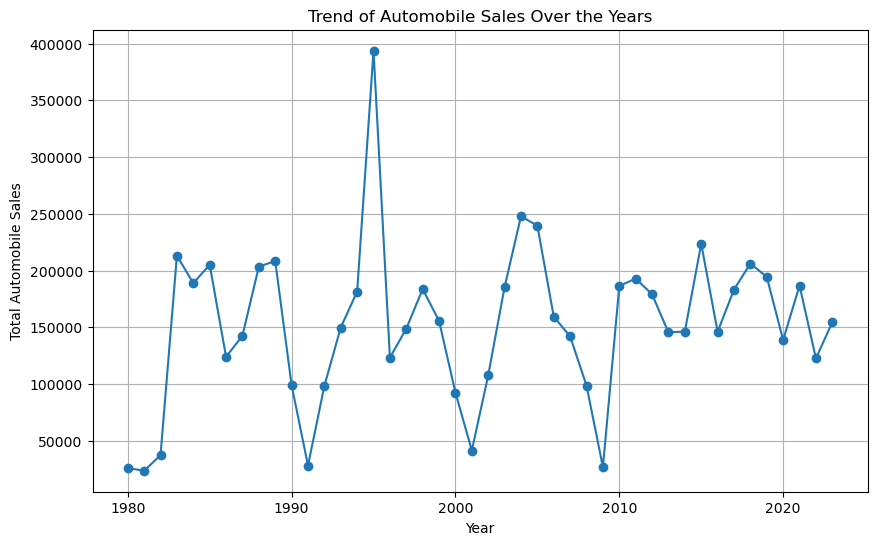

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    df_total_sales["Year"],
    df_total_sales["Automobile_Sales"],
    marker='o'
)

plt.title("Trend of Automobile Sales Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Automobile Sales")

plt.grid(True)

plt.show()


We are now going to plot a line chart to show the Automobile sales in the periods.

In [65]:
auto_sales_df=(df.groupby(['Year','Recession'])['Automobile_Sales'].mean().reset_index())

In [66]:
rec_data=auto_sales_df[auto_sales_df['Recession']==1]
non_rec_df=auto_sales_df[auto_sales_df['Recession']==0]

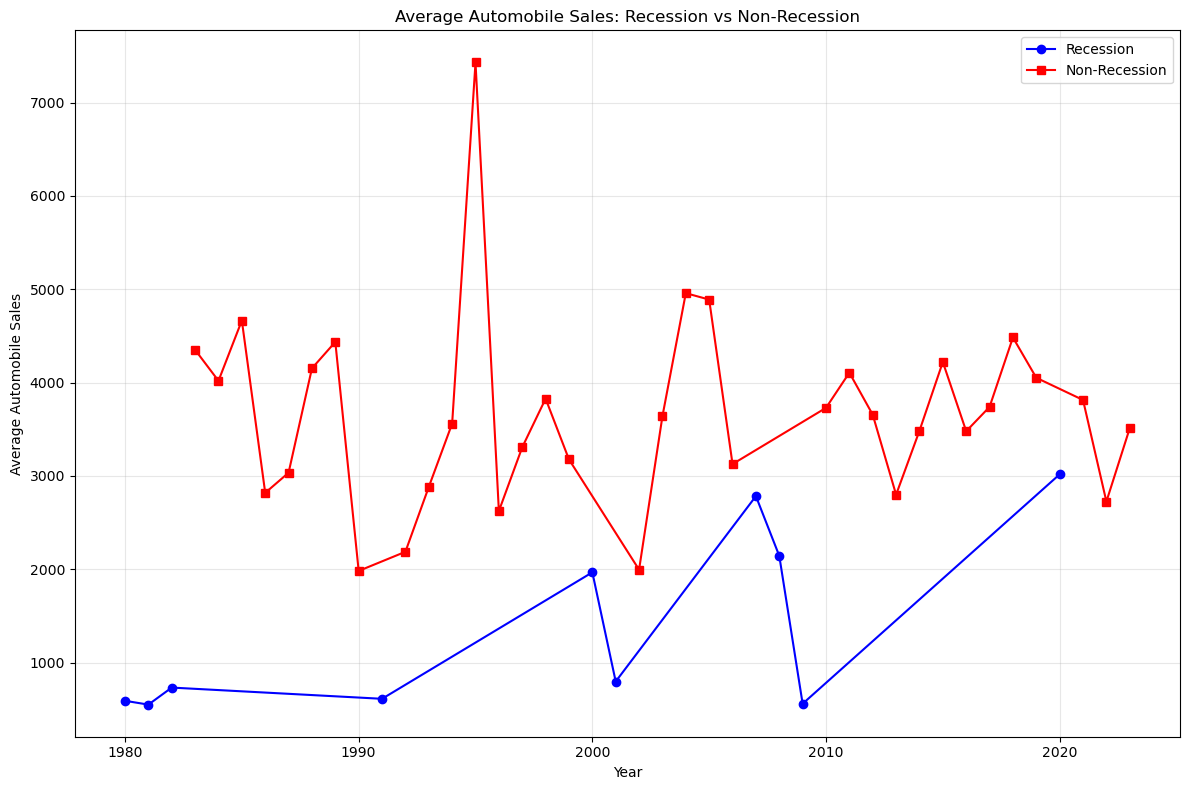

In [70]:
plt.figure(figsize=(12,8))

plt.plot(
    'Year',
    'Automobile_Sales',
    marker='o',
    label='Recession',
    color='b',
    data=rec_data
)

plt.plot(
    'Year',
    'Automobile_Sales',
    marker='s',
    label='Non-Recession',
    color='r',
    data=non_rec_df          
)

plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales: Recession vs Non-Recession')

plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

To ensure a fair comparison between recession and non-recession periods, average automobile sales were used instead of total sales. Since recession periods are shorter and occur irregularly, using totals would bias the comparison toward non-recession years. The mean provides a normalized measure of sales performance across economic conditions.

#### Insight

As you can see it is evident that during the non recession period the Average Sales were consideratively higher compared to recession periods

### 5.2 Trend in Unemployment rate for both recession and recession periods

In [60]:
unemp_rate_df= (df.groupby('Year')['Unemployment_Rate'].mean().reset_index())

In [61]:
unemp_rate_df

,Year,Unemployment_Rate
0,1980,4.009091
1,1981,4.074419
2,1982,4.145098
3,1983,2.202041
4,1984,2.019149
5,1985,1.859091
6,1986,1.956818
7,1987,2.093617
8,1988,2.236735
9,1989,1.642553


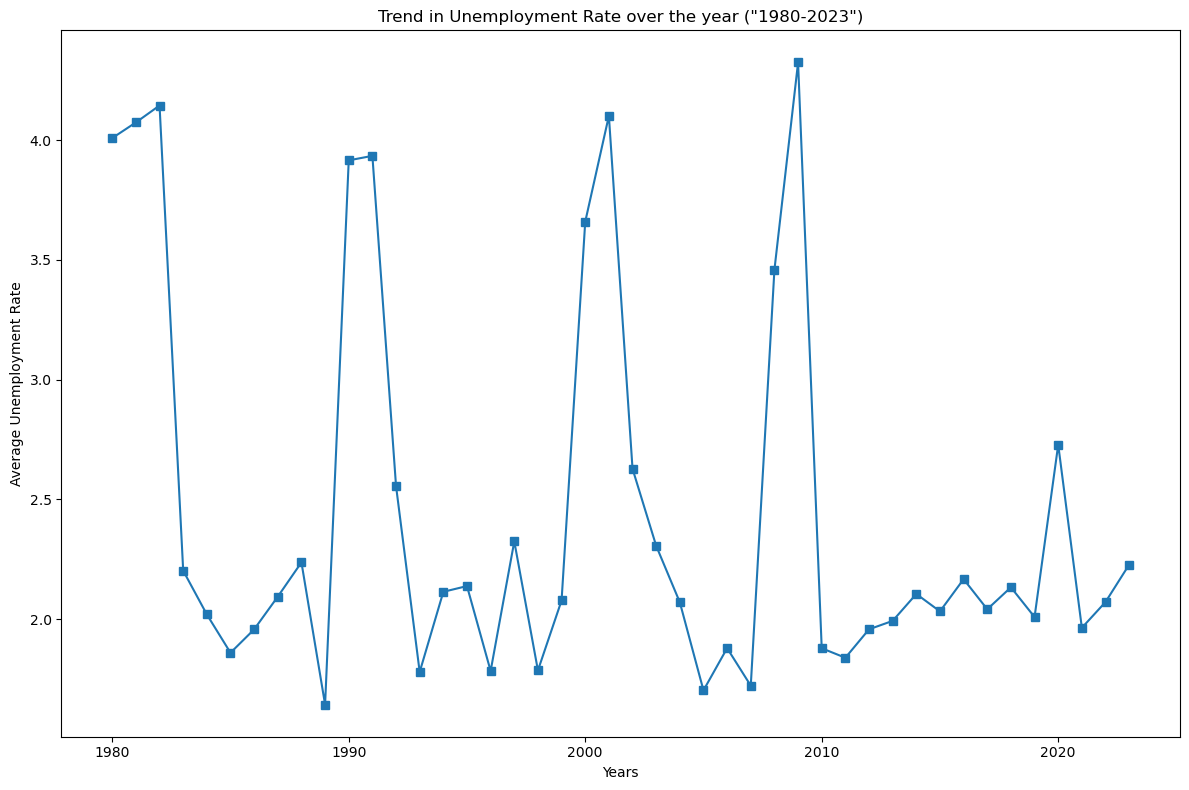

In [35]:
plt.figure(figsize=(12,8))

plt.plot(
    'Year',
    'Unemployment_Rate',
     label=('Unemployment Rate')
    linewidth=2,
     data= unemp_rate_df,
     marker='s'
)

plt.xlabel('Years')
plt.ylabel('Average Unemployment Rate')
plt.title('Trend in Unemployment Rate over the year ("1980-2023")')
plt.tight_layout()
plt.show()

#### Lets plot to compare the unemployment between the two periods

In [38]:
rec_unemp=df[df['Recession']==1]
non_rec_unemp=df[df['Recession']==0]

In [40]:
rec_unemp_trend=(rec_unemp.groupby('Year')['Unemployment_Rate'].mean().reset_index())
non_rec_unemp_trend=(non_rec_unemp.groupby('Year')['Unemployment_Rate'].mean().reset_index())

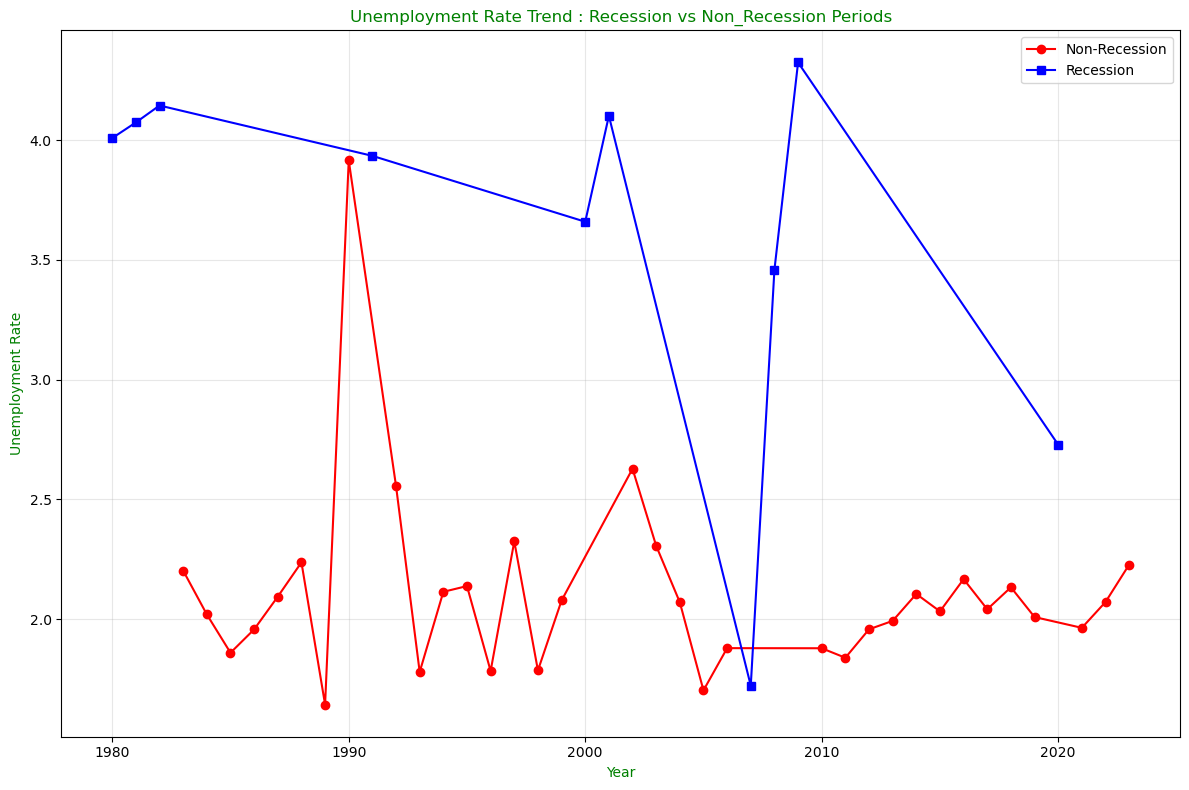

In [71]:
plt.figure(figsize=(12, 8))

plt.plot(
    'Year',
    'Unemployment_Rate',
    marker='o',
    label='Non-Recession',
    color='r',
    data=non_rec_unemp_trend
)
plt.plot(
    'Year',
    'Unemployment_Rate',
    marker='s',
    label='Recession',
    color='b',
    data=rec_unemp_trend
)

plt.xlabel('Year', color='g')
plt.ylabel('Unemployment Rate', color='g')
plt.title('Unemployment Rate Trend : Recession vs Non_Recession Periods', color='g')

plt.tight_layout()
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Insight:

The unemployment rate is consistently higher during recession periods compared to non-recession periods. Recession years also exhibit greater volatility, indicating economic instability and increased job losses. This helps explain reduced automobile sales during recession periods due to lower consumer purchasing power


As you can see from our graph the recession line has fewer lines but its because recession only happens in few years

**We will also check when the unemployment rate was high whether during the recession or non recession period**

In [101]:
df_unemp=(df.groupby('Recession')['Unemployment_Rate'].sum().reset_index())

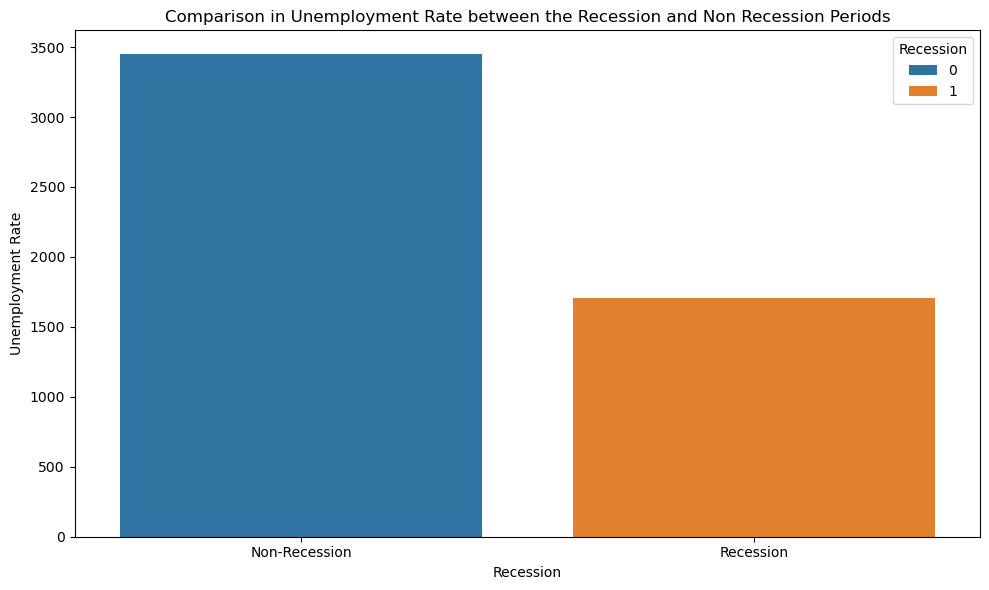

In [102]:
plt.figure(figsize=(10,6))

plt.xticks(ticks=[1,0], labels=['Recession', 'Non-Recession'])
sns.barplot(x='Recession', y='Unemployment_Rate', hue='Recession', data=df_unemp)

plt.xlabel('Recession')
plt.ylabel('Unemployment Rate')
plt.title('Comparison in Unemployment Rate between the Recession and Non Recession Periods')

plt.tight_layout()
plt.show()

#### Insight
While line charts indicate that unemployment spikes sharply during recession periods, aggregated bar charts may show higher average unemployment during non-recession periods. This occurs because unemployment typically lags behind recessions and remains elevated during post-recession recovery years, which are labeled as non-recession. Therefore, both visualizations are consistent and reflect different temporal aspects of labor market behavior.

### 5.3 Lets now compare the Automobile sales with the Unemployment rate

In this plot we will be determining how unemployment affects the automobile sales weather positive or negative or not at all. <br>
THe plot will be a scatter plot

In [48]:
new_data=(df.groupby('Year')[['Unemployment_Rate', 'Automobile_Sales']].mean().reset_index())

In [49]:
new_data

,Year,Unemployment_Rate,Automobile_Sales
0,1980,4.009091,590.020455
1,1981,4.074419,549.170233
2,1982,4.145098,731.627451
3,1983,2.202041,4350.265306
4,1984,2.019149,4018.361702
5,1985,1.859091,4664.409091
6,1986,1.956818,2817.954545
7,1987,2.093617,3033.638298
8,1988,2.236735,4152.224490
9,1989,1.642553,4435.021277


Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'Unemployment_Rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

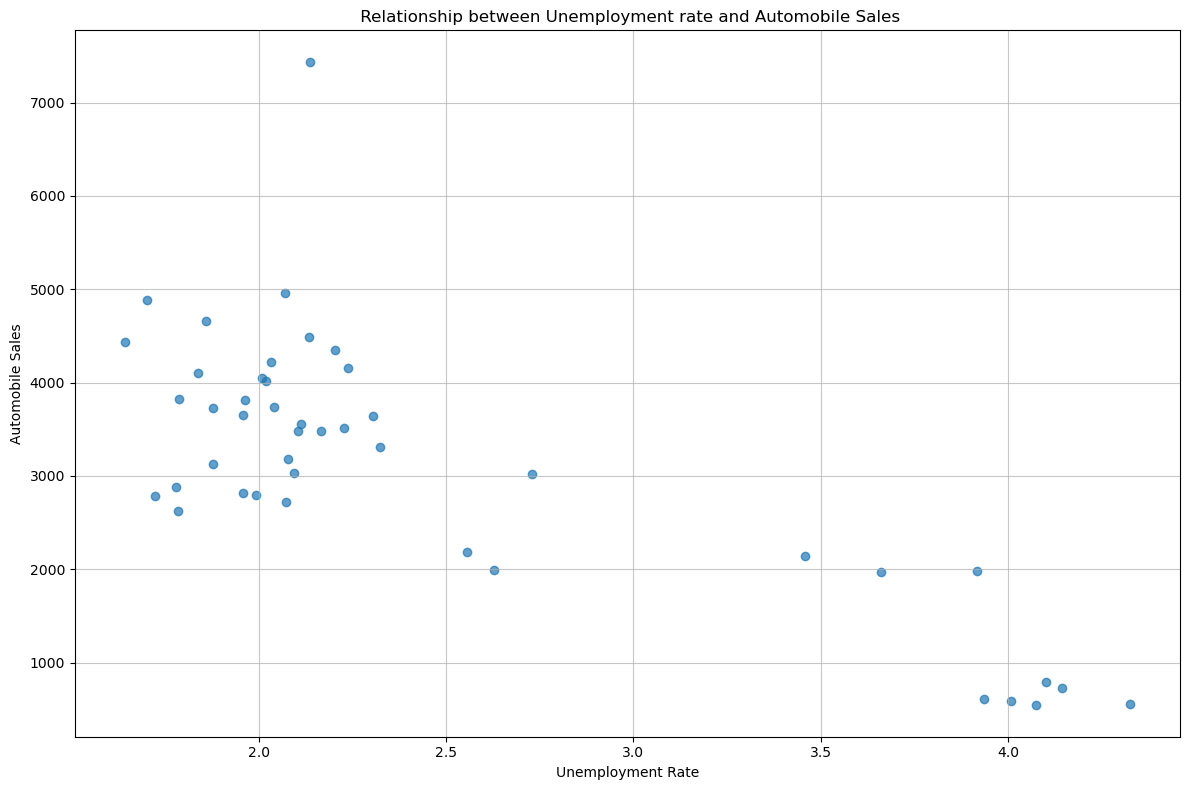

In [56]:
plt.figure(figsize=(12, 8))

plt.scatter(
    'Unemployment_Rate',
    'Automobile_Sales',
    alpha=0.7,
    data= new_data
)
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.title(' Relationship between Unemployment rate and Automobile Sales')

plt.grid(alpha=0.7)
plt.tight_layout()
plt.show()

#### Insight
So here from our plot it is evident that Unemployment generally affects the automobile sales negatively this because when the unemployment rate is low , The sales tend to be higher considered to when the unemployment rate is high the average sales are lower

### 5.4 Automobile Sales vs Advertising expenditure

Here we are going to consider whether spending more on advertisement contributes to increased total sales or not.<br>
So we are going to split the data into two parts because advertising effectiveness changes with economic conditions. We will also plot a bar chart to compare which season spend more on advertising is it during recession or non recession periods.

In [78]:
df_advert=(df.groupby(['Year', 'Recession'])[['Advertising_Expenditure', 'Automobile_Sales']].mean().reset_index())

In [79]:
df_rec_advert=df_advert[df_advert['Recession']==1]
df_non_rec_advert=df_advert[df_advert['Recession']==0]

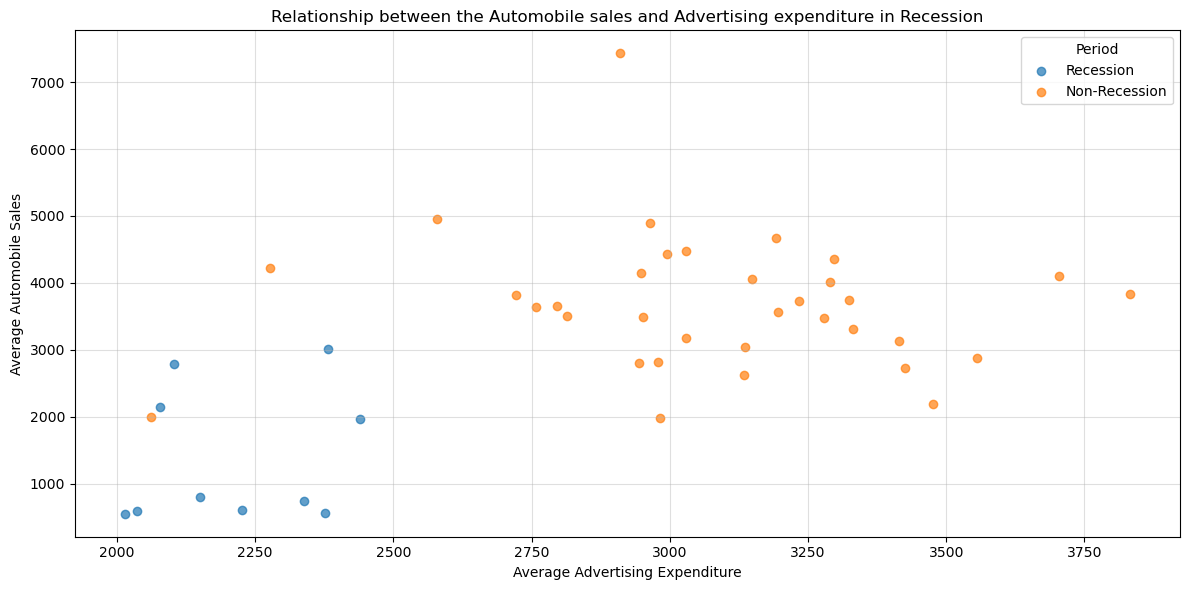

In [124]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_rec_advert['Advertising_Expenditure'],
     df_rec_advert['Automobile_Sales'],
    alpha=0.7,
    label='Recession'
)

plt.scatter(
    df_non_rec_advert['Advertising_Expenditure'],
     df_non_rec_advert['Automobile_Sales'],
    alpha=0.7,
    label='Non-Recession'
)

plt.xlabel('Average Advertising Expenditure')
plt.ylabel('Average Automobile Sales')
plt.title('Relationship between the Automobile sales and Advertising expenditure in Recession')

plt.grid(True, alpha=0.4)
plt.legend(title='Period')
plt.tight_layout()
plt.show()

           

In [88]:
df_rec_advert[['Advertising_Expenditure', 'Automobile_Sales']].corr()
df_non_rec_advert[['Advertising_Expenditure', 'Automobile_Sales']].corr()

,Advertising_Expenditure,Automobile_Sales
Advertising_Expenditure,1.000000,-0.069018
Automobile_Sales,-0.069018,1.000000


### Insight 
Advertising expenditure shows a weaker and more volatile relationship with automobile sales during recession periods, indicating reduced marketing effectiveness under economic stress. In contrast, non-recession periods exhibit a clearer positive association, suggesting higher responsiveness to advertising.  It is evident also as we calculate correlation above.

**Lets check which period Consumed more on Advertising by plotting a bar plot** <br>


In [93]:
advert_df=(df.groupby('Recession')['Advertising_Expenditure'].sum().reset_index())

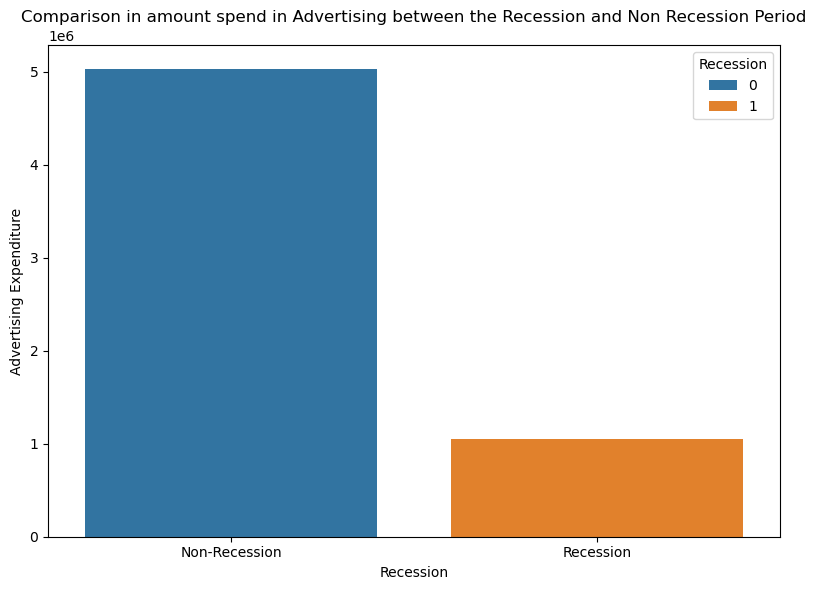

In [94]:
plt.figure(figsize=(8,6))

plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
sns.barplot(x='Recession', y='Advertising_Expenditure', hue='Recession', data=advert_df)
plt.xlabel('Recession')
plt.ylabel('Advertising Expenditure')
plt.title('Comparison in amount spend in Advertising between the Recession and Non Recession Period')

plt.tight_layout()
plt.show()

So from the graph the inference made shows that during the **Non-Recession** period the business spend more in advertising compared to **Recession** Period

### 5.5 Vehicle_Type 
We will be checking which vehicle sales the most in the periods and we will group data by recession

In [104]:
veh_df=(df.groupby('Vehicle_Type')['Automobile_Sales'].sum().reset_index())

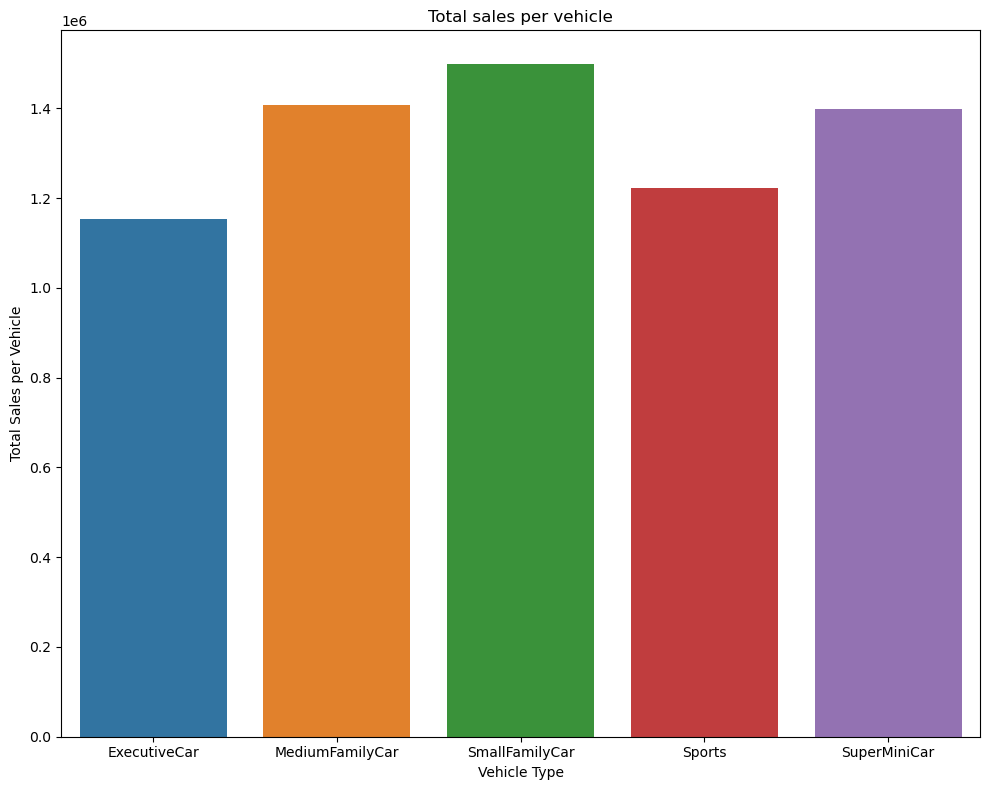

In [112]:
plt.figure(figsize=(10, 8))

sns.barplot(x='Vehicle_Type', y='Automobile_Sales', hue='Vehicle_Type', data=veh_df, estimator=sum)

plt.xlabel('Vehicle Type')
plt.ylabel('Total Sales per Vehicle')
plt.title('Total sales per vehicle')
plt.tight_layout()
plt.show()

So now from the graph it is evident that small family car contributed to the highest sales while the Exacutive car contributed the lowest sales

**We will now compare the sales for both periods**

In [118]:
veh_data=(df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().reset_index())

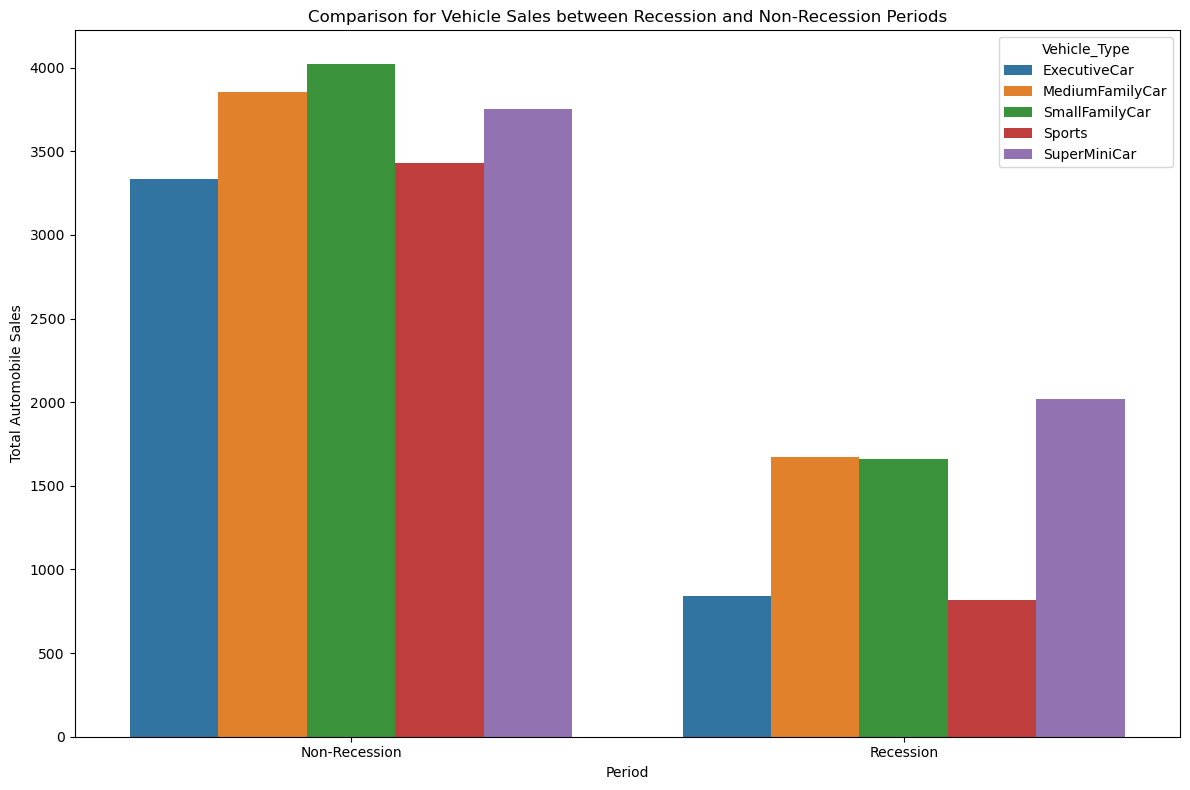

In [121]:
plt.figure(figsize=(12, 8))

plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=veh_data)
plt.xlabel('Period')
plt.ylabel('Total Automobile Sales')
plt.title('Comparison for Vehicle Sales between Recession and Non-Recession Periods')

plt.tight_layout()
plt.legend(title='Vehicle_Type')
plt.show()

#### Insight 
According to this provided graph it indicates that during the non-recession period, Small Family Car accounted to the most sales compared to the other vehicles while During the Recession period the Super mini car contributed to the most sales with Executive car selling the lowest

In [122]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,Unemployment_Rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


### 5.6  Lets now check how the Price of vehicles in the Periods whether contributed to any sales

We will fast plot a scatter plot to check the relationship between price and automobile sales in the periods so we will filter the data according to periods

In [123]:
price_rec_df=df[df['Recession']==1]
price_nonrec_df=df[df['Recession']==0]

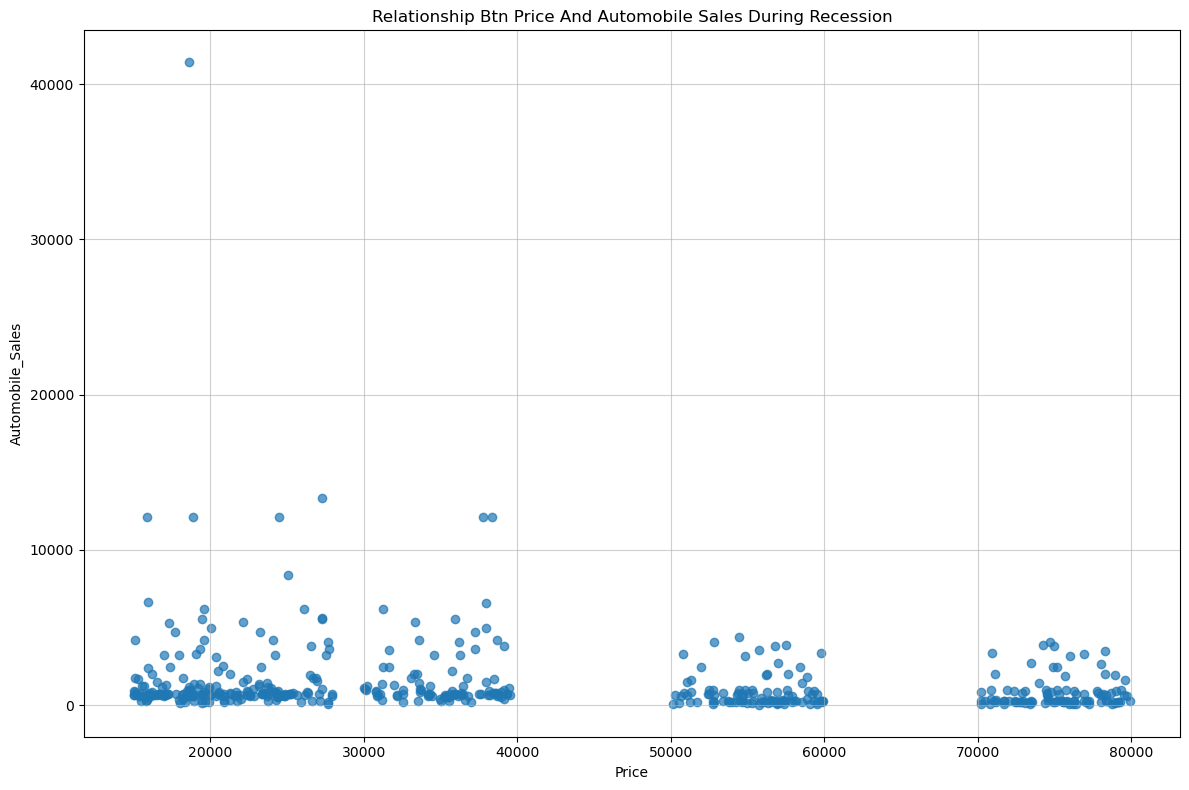

In [128]:
plt.figure(figsize=(12,8))

plt.scatter(
    'Price',
    'Automobile_Sales',
    alpha=0.7,
    data=price_rec_df
)

plt.xlabel('Price')
plt.ylabel('Automobile_Sales')
plt.title('Relationship Btn Price And Automobile Sales During Recession')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

#### Insight
The graph indicates that during the recession period, automobile sales are not strongly influenced by price. Although lower-priced vehicles show slightly higher sales volumes compared to higher-priced vehicles, the overall relationship between price and total automobile sales remains weak, suggesting that factors beyond price play a more significant role in determining sales during economic downturns.

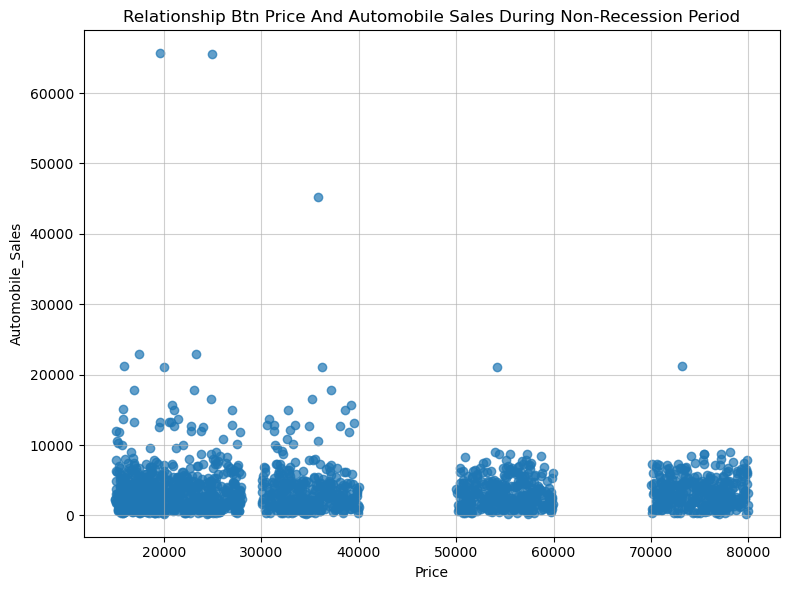

In [129]:
plt.figure(figsize=(8,6))

plt.scatter(
    'Price',
    'Automobile_Sales',
    alpha=0.7,
    data=price_nonrec_df
)

plt.xlabel('Price')
plt.ylabel('Automobile_Sales')
plt.title('Relationship Btn Price And Automobile Sales During Non-Recession Period')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

#### Insight
During the non-recession period, automobile sales do not show a strong dependence on price, as sales volumes remain widely distributed across all price ranges. However, higher sales concentrations are observed among lower to mid-priced vehicles, suggesting that affordability contributes to higher sales volumes, even though price alone is not the primary driver of demand.

In [131]:
price_rec_df[['Price', 'Automobile_Sales']].corr()
price_nonrec_df[['Price', 'Automobile_Sales']].corr()

,Price,Automobile_Sales
Price,1.00000,-0.05747
Automobile_Sales,-0.05747,1.00000


### 5.7 We will now compare GDP with other factors in our data set

**Lets now fast check the trend in GDP over the years**

In [132]:
gdp_data=(df.groupby('Year')['GDP'].mean().reset_index())

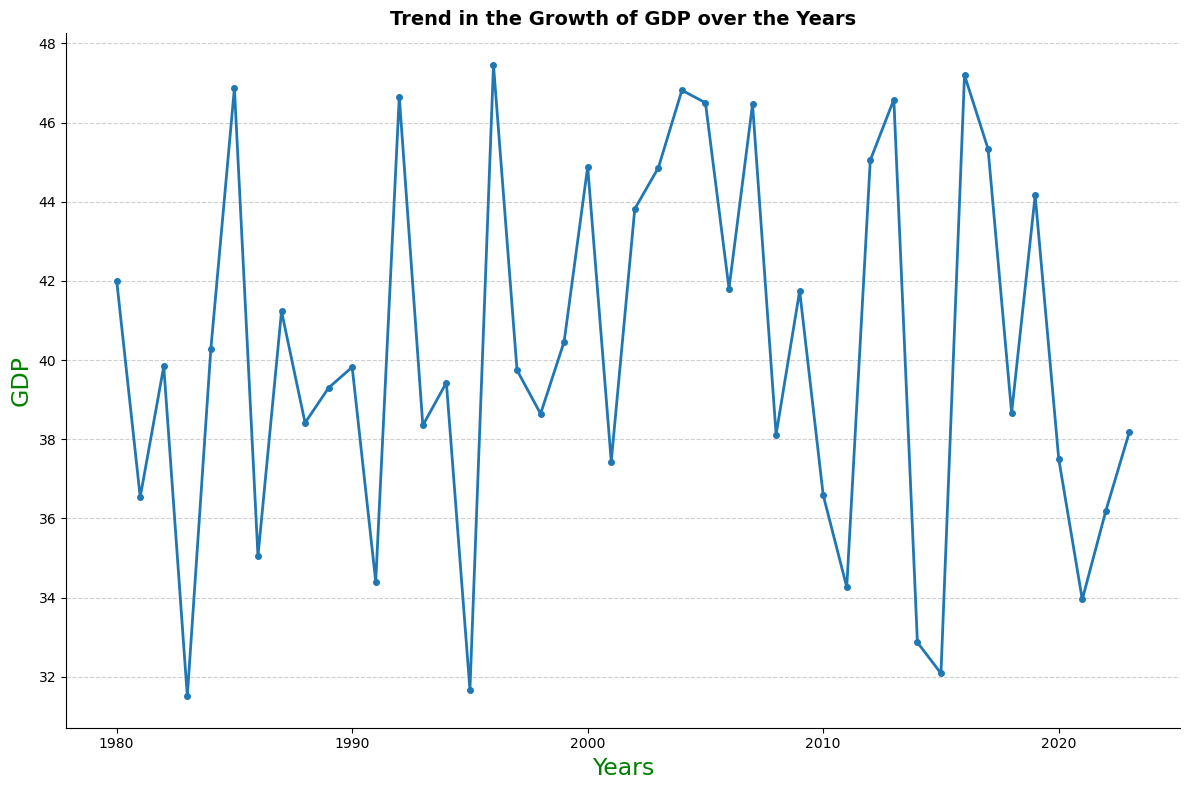

In [137]:
plt.figure(figsize=(12,8))

plt.plot(
    'Year',
    'GDP',
    marker='o',
    markersize=4,
    linewidth=2,
    data=gdp_data,
)

plt.xlabel('Years', fontsize=17, color='g')
plt.ylabel('GDP', fontsize=17, color='g')
plt.title('Trend in the Growth of GDP over the Years', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.grid(alpha=0.6,linestyle='--', axis='y')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

#### Insight
The GDP trend over the years shows fluctuations reflecting cyclical economic behavior rather than consistent growth. Periods of sharp decline suggests the presence of economic slowdowns or recessions, followed by phases. This pattern highlights the sensitivity of GD to macroeconomic conditions and provides important context when analyzing trends in automobile sales and consumer demand.  We will see how the periods affect GDP by comparing them with the line graphs

In [139]:
gdp_rec=(df.groupby(['Year', 'Recession'])['GDP'].mean().reset_index())
nongdp_rec=(df.groupby(['Year', 'Recession'])['GDP'].mean().reset_index())

In [140]:
plt.figure(figsize=(12, 8))

plt.plot(
    'Year',
    'GDP',
    linewidth=3,
    marker='o',
    markersize='2',
    linestyle='--',
    color='r',
    data=gdp_rec,
    plt.subplots(1,2,1)
)
plt.plot(
    'Year',
    'GDP',
    linewidth=2,
    marker='s',
    markersize='2',
    color='b',
    data=nongdp_rec,
    plt.subplots(1,2,2)
)

plt.xlabel('Year', fontsize=13)
plt.ylabel('GDP', fontsize=13)
plt.title('Trend in GDP for Recession and Non Recession Periods')

plt.tight_layout()
plt.show()


SyntaxError: positional argument follows keyword argument (2082712073.py, line 13)

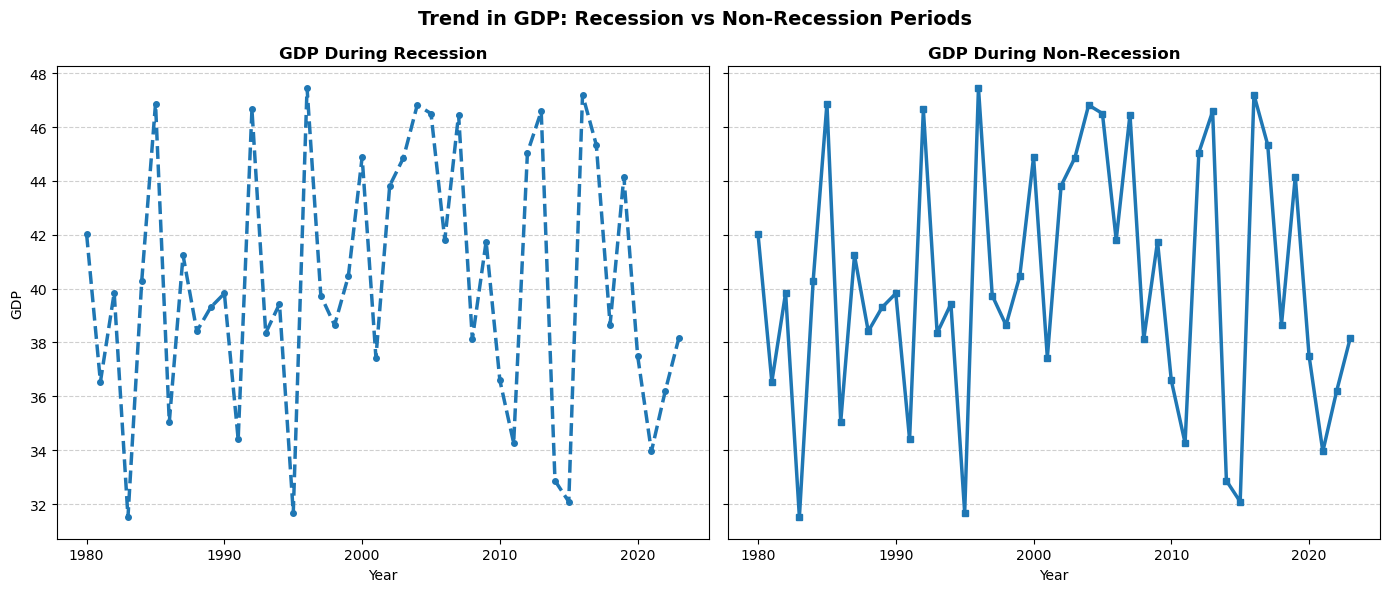

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# -------- Recession GDP --------
axes[0].plot(
    gdp_rec['Year'],
    gdp_rec['GDP'],
    linewidth=2.5,
    marker='o',
    markersize=4,
    linestyle='--'
)

axes[0].set_title('GDP During Recession', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# -------- Non-Recession GDP --------
axes[1].plot(
    nongdp_rec['Year'],
    nongdp_rec['GDP'],
    linewidth=2.5,
    marker='s',
    markersize=4
)

axes[1].set_title('GDP During Non-Recession', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Main title
fig.suptitle(
    'Trend in GDP: Recession vs Non-Recession Periods',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


In [142]:
df.to_csv('vehicle_sales.csv', index=False)

In [143]:
vehicle_sales.head()

NameError: name 'vehicle_sales' is not defined

In [144]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,Unemployment_Rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [145]:
df.to_csv('vehicle_sales.csv', index=False)